In [39]:
import numpy as np
import glob
import cv2
from torch.utils.data import DataLoader
import albumentations as A
from datasets import Dataset, load_from_disk
from transformers import Mask2FormerImageProcessor
import torch
from PIL import Image

In [40]:
from transformers import Mask2FormerForUniversalSegmentation


category_info = {0: 'Background', 1: 'Lower Jaw', 2: 'Tooth', 3: 'Other Bone'}


class Model:
    def __init__(self, checkpoint=None):
        if checkpoint:
            self.model = Mask2FormerForUniversalSegmentation.from_pretrained(checkpoint, local_files_only=True)
        else:
            self.model = Mask2FormerForUniversalSegmentation.from_pretrained('facebook/mask2former-swin-base-coco-panoptic', id2label=category_info, ignore_mismatched_sizes=True)


In [41]:
m = Model("saved_models/model1")


In [42]:
from torch.utils.data import Dataset
import numpy as np
import torch
import io
from PIL import Image

class UJDataset(Dataset):
    """Pytorch Dataset for preprocessed lizard scans with upper jaw and skull also segmented"""

    def __init__(self, dataset, processor, transform=None):
        self.dataset = dataset
        self.processor = processor
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image = np.array(self.dataset[idx]['image'], dtype=np.float32)
        #image = np.array(Image.open(io.BytesIO(self.dataset[idx]['image']['bytes'])), dtype=np.float32)
        panoptic_seg_gt = np.array(self.dataset[idx]['label'], dtype=np.float32)

        if self.transform is not None:
            transformed = self.transform(image= image, mask= panoptic_seg_gt)
            image, panoptic_seg_gt = transformed['image'], transformed['mask']
            image = image.transpose(2,0,1)

        inst2class = {segment['id']: segment['category_id'] for segment in self.dataset[idx]['segments_info']}

        inputs = self.processor([image], [panoptic_seg_gt], instance_id_to_semantic_id=inst2class, return_tensors='pt')
        inputs = {k: v.squeeze() if isinstance(v, torch.Tensor) else v[0] for k, v in inputs.items()}
        return inputs

In [43]:
data = load_from_disk("ThreeScanDataset split.hf")
testdata = load_from_disk("TwoScanDataset split test.hf")
processor = Mask2FormerImageProcessor(ignore_index=0, do_resize=False, do_rescale=False, do_normalize=False)

train = data['Train']
val = testdata['Test']


transform = A.Compose([
    A.Resize(width=256, height=512),
    A.ToRGB(),
    A.HorizontalFlip(p=1.0)
])

train_ds = UJDataset(train, processor, transform)
val_ds = UJDataset(val, processor, transform)

def collate_fn(batch):
    pixel_values = torch.stack([example["pixel_values"] for example in batch])
    pixel_mask = torch.stack([example["pixel_mask"] for example in batch])
    class_labels = [example["class_labels"] for example in batch]
    mask_labels = [example["mask_labels"] for example in batch]
    return {"pixel_values": pixel_values, "pixel_mask": pixel_mask, "class_labels": class_labels, "mask_labels": mask_labels}

train_dataloader = DataLoader(train_ds, batch_size=2, shuffle=True, collate_fn=collate_fn)
val_dataloader = DataLoader(val_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)

In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
m.model.to(device)

Mask2FormerForUniversalSegmentation(
  (model): Mask2FormerModel(
    (pixel_level_module): Mask2FormerPixelLevelModule(
      (encoder): SwinBackbone(
        (embeddings): SwinEmbeddings(
          (patch_embeddings): SwinPatchEmbeddings(
            (projection): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
          )
          (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (encoder): SwinEncoder(
          (layers): ModuleList(
            (0): SwinStage(
              (blocks): ModuleList(
                (0-1): 2 x SwinLayer(
                  (layernorm_before): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
                  (attention): SwinAttention(
                    (self): SwinSelfAttention(
                      (query): Linear(in_features=128, out_features=128, bias=True)
                      (key): Linear(in_features=128, out_features=128, bias=True)
                     

In [45]:
import torchmetrics

In [46]:
outlist = []
tlist = []
gtlist = []
for idx, batch in enumerate(val_dataloader):
  m.model.eval()
  with torch.no_grad():
    o = m.model(
      pixel_values=batch["pixel_values"],
      mask_labels=[labels for labels in batch["mask_labels"]],
      class_labels=[labels for labels in batch["class_labels"]]
    )
    tlist.append(batch['pixel_values'])
    gtlist.append((batch['class_labels'][0], batch['mask_labels'][0]))
    #outlist.append(processor.post_process_panoptic_segmentation(outputs=o, label_ids_to_fuse=[0, 1, 3], target_sizes=[(batch['pixel_values'][0].shape[1], batch['pixel_values'][0].shape[2])])[0])
    outlist.append(processor.post_process_panoptic_segmentation(outputs=o, label_ids_to_fuse=[0, 1, 3], target_sizes=[(512, 256)])[0])
  print(idx, processor.post_process_panoptic_segmentation(outputs=o, label_ids_to_fuse=[0, 1, 3])[0]['segments_info'])

0 [{'id': 1, 'label_id': 1, 'was_fused': True, 'score': 0.999586}, {'id': 2, 'label_id': 3, 'was_fused': True, 'score': 0.999669}, {'id': 3, 'label_id': 0, 'was_fused': True, 'score': 0.998917}]
1 [{'id': 1, 'label_id': 2, 'was_fused': False, 'score': 0.958304}, {'id': 2, 'label_id': 1, 'was_fused': True, 'score': 0.999355}, {'id': 3, 'label_id': 3, 'was_fused': True, 'score': 0.999653}, {'id': 4, 'label_id': 0, 'was_fused': True, 'score': 0.999191}]
2 [{'id': 1, 'label_id': 2, 'was_fused': False, 'score': 0.976684}, {'id': 2, 'label_id': 1, 'was_fused': True, 'score': 0.999575}, {'id': 3, 'label_id': 3, 'was_fused': True, 'score': 0.999696}, {'id': 4, 'label_id': 0, 'was_fused': True, 'score': 0.999242}]
3 [{'id': 1, 'label_id': 2, 'was_fused': False, 'score': 0.971261}, {'id': 2, 'label_id': 1, 'was_fused': True, 'score': 0.999558}, {'id': 3, 'label_id': 3, 'was_fused': True, 'score': 0.999704}, {'id': 4, 'label_id': 0, 'was_fused': True, 'score': 0.999257}]
4 [{'id': 1, 'label_id': 

In [47]:
print(gtlist[0][0])

tensor([0, 1, 2, 3])


In [48]:
flist = []
for x in gtlist:
    tens = torch.zeros(size=x[1].shape[-2:], dtype=torch.int32)
    t2 = tens.detach().clone()
    for y in range(x[0].shape[0]):
        print(np.unique(x[1][y, :, :]))
        l = [x[1][y, :, :].int() != 0]
        tens[l] = x[0][y]
        t2[l] = y
    flist.append(torch.stack((tens, t2), dim=-1))
    


[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]


In [49]:
print(np.unique(flist[0][:, :,0]))

[0 1 2 3]


In [50]:
f2list = []
for k in outlist:
    temp = k['segmentation']
    t2 = temp.detach().clone()
    for f in k['segments_info']:
        t2[temp == f['id']] = f['label_id']
    final = torch.stack((t2, temp), dim=-1)
    f2list.append(final)

In [51]:
print(np.unique(f2list[0][:, :, 0]))

[0 1 3]


In [52]:
pred = torch.stack(f2list, dim=0)
gt = torch.stack(flist, dim=0)

In [53]:
pq = torchmetrics.detection.PanopticQuality(things={2}, stuffs={0, 1, 3}, return_sq_and_rq=True, return_per_class=True)

In [54]:
print(pq(pred, gt))

tensor([[0.3974, 0.6585, 0.6036],
        [0.9874, 0.9874, 1.0000],
        [0.7884, 0.8040, 0.9806],
        [0.8457, 0.8457, 1.0000]], dtype=torch.float64)


In [120]:
import copy
tout = copy.deepcopy(outlist)

#start at 2, labels 0 and 1 assigned to background and lower jaw
tooth_label_val = 2

for idx, frame in enumerate(output):
    for segment in segments_info[idx]:
        #modify tooth values to prepare for combining
        if segment['label_id'] == 2:
            frame[segment['id']] += 1000
        #change background and upper jaw values to 0
        elif segment['label_id'] == 0 or segment['label_id'] == 3:
            frame[segment['id']] = 0
        #change lower jaw values to 1
        else:
            frame[segment['id']] = 1

#apply find_corresponding_tooth to each frame
for idx, frame in enumerate(output):
    if idx <= (len(output)-1)
        for value in np.unique(frame) where (value !=0 and value !=1):
            corresponding_tooth_val = find_corresponding_tooth(frame[frame == value], output[idx + 1][frame == value])
            if corresponding_tooth_val != 0:
                output[idx + 1][output[idx + 1] == corresponding_tooth_val] = value

Do a final check to fill in slices that are missing in between?
    


Calculate overlap of pixel sets on adjacent frames
def calc_overlap(set1, set2):
    #return number of pixels in set2 

choose which value on second fram corresponds best to area on first frame
def find_corresponding_tooth(source_pixels, target_pixels):
    best_fit, max_overlap = 0, 0
    for value in np.unique(target_pixels) where (value !=0 and value !=1):
        t = calc_overlap(source_pixels, target_pixels[target_pixels == value])
        if t > max_overlap:
            best_fit, max_overlap = value, t
    return best_fit


In [130]:
def calc_overlap(set1, set2_intersect, set2_max):
    union = np.count_nonzero(set1) + np.count_nonzero(set2_max) - np.count_nonzero(set2_intersect)
    return np.count_nonzero(set2_intersect) / union

In [131]:
#choose which value on second frame corresponds best to area on first frame
def find_corresponding_tooth(source_pixels, target_frame, target_pixels):
    best_fit, max_overlap = 0, 0
    for val in np.unique(target_pixels):
        target_pixels = target_frame[target_frame == val]
        if((val !=0 and val !=1)):
            t = calc_overlap(source_pixels, target_pixels[target_pixels == val], target_frame[target_frame == val])
            if t > max_overlap:
                best_fit, max_overlap = val, t
    if max_overlap < 0.1:
        best_fit = 0
    return best_fit

In [123]:
print(tout[78])

{'segmentation': tensor([[2, 2, 2,  ..., 2, 2, 2],
        [2, 2, 2,  ..., 2, 2, 2],
        [2, 2, 2,  ..., 2, 2, 2],
        ...,
        [2, 2, 2,  ..., 2, 2, 2],
        [2, 2, 2,  ..., 2, 2, 2],
        [2, 2, 2,  ..., 2, 2, 2]], dtype=torch.int32), 'segments_info': [{'id': 1, 'label_id': 3, 'was_fused': True, 'score': 0.992345}, {'id': 2, 'label_id': 0, 'was_fused': True, 'score': 0.992941}]}


In [132]:
outlist = copy.deepcopy(tout)
for f in outlist:
    f['segmentation'] = f['segmentation'].numpy()

In [101]:
for idx, out in enumerate(outlist):
    frame = out['segmentation']
    f2 = copy.deepcopy(frame)
    segments_info = out['segments_info']
    for segment in segments_info:
        #modify tooth values to prepare for combining
        if segment['label_id'] == 2:
            #frame[f2 == segment['id']] += 1000
            pass
        #change background and upper jaw values to 0
        elif segment['label_id'] == 0 or segment['label_id'] == 3:
            frame[f2 == segment['id']] = 0
        #change lower jaw values to 1
        else:
            frame[f2 == segment['id']] = 1
    #print(np.unique(frame))

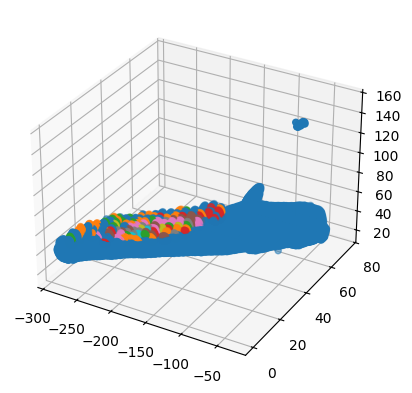

In [102]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

array_3d = np.stack([f['segmentation'] for f in outlist], axis=-1)

# Create a figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Extract x, y, z coordinates
x, y, z = array_3d.nonzero()
ax.scatter(-x, z, y, c=array_3d[x, y, z], cmap='tab10')

plt.show()

In [76]:
print(outlist[78], len(outlist))

{'segmentation': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]]), 'segments_info': [{'id': 1, 'label_id': 3, 'was_fused': True, 'score': 0.996028}, {'id': 2, 'label_id': 0, 'was_fused': True, 'score': 0.996177}]} 79


In [133]:
tooth_label_val = 2


for idx, out in enumerate(outlist):
    frame = out['segmentation']
    f2 = copy.deepcopy(frame)
    segments_info = out['segments_info']
    for segment in segments_info:
        #modify tooth values to prepare for combining
        if segment['label_id'] == 2:
            frame[f2 == segment['id']] += 1000
        #change background and upper jaw values to 0
        elif segment['label_id'] == 0 or segment['label_id'] == 3:
            frame[f2 == segment['id']] = 0
        #change lower jaw values to 1
        else:
            frame[f2 == segment['id']] = 1
    #print(np.unique(frame))

#apply find_corresponding_tooth to each frame
for idx, out in enumerate(outlist):
    frame = out['segmentation']
    if idx == 0:
        x = np.unique(frame)
        for value in x:
            if(value !=0 and value !=1):
                print(value)
                tval = value
                if value >= 1000:
                    tval = tooth_label_val
                frame[frame == value] = tval
                if value >= 1000:
                    tooth_label_val = tooth_label_val + 1
        print(np.unique(frame))
    if idx <= (len(outlist)-2):
        x = np.unique(frame)
        print(x)
        for value in x:
            if(value !=0 and value !=1):
                print(value)
                next_frame = outlist[idx + 1]['segmentation']
                corresponding_tooth_val = find_corresponding_tooth(frame[frame == value], next_frame, next_frame[frame == value])
                tval = value
                if value >= 1000:
                    tval = tooth_label_val
                frame[frame == value] = tval
                if corresponding_tooth_val != 0 and corresponding_tooth_val != 1:
                    next_frame[next_frame == corresponding_tooth_val] = tval
                if value >= 1000:
                    tooth_label_val = tooth_label_val + 1
                outlist[idx + 1]['segmentation'] = next_frame

[0 1]
[0 1]
[   0    1 1001]
1001
[0 1 2]
2
[0 1 2]
2
[0 1 2]
2
[0 1 2]
2
[0 1 2]
2
[0 1 2]
2
[0 1 2]
2
[0 1 2]
2
[   0    1    2 1001]
2
1001
[   0    1    3 1001]
3
1001
[   0    1    4 1002]
4
1002
[0 1 5]
5
[0 1 5]
5
[   0    1    5 1002]
5
1002
[   0    1    6 1002 1004 1006]
6
1002
1004
1006
[0 1 7 9]
7
9
[0 1 7 9]
7
9
[   0    1    9 1002 1005]
9
1002
1005
[   0    1    9   11 1005]
9
11
1005
[   0    1    9   12 1006]
9
12
1006
[   0    1    9   12   13 1002]
9
12
13
1002
[   0    1    9   12   13   14 1007]
9
12
13
14
1007
[   0    1    9   14   15 1002 1005]
9
14
15
1002
1005
[   0    1   14   15   16   17 1005 1009]
14
15
16
17
1005
1009
[   0    1   17   18   19 1005]
17
18
19
1005
[   0    1   17   18   19   20 1001 1006]
17
18
19
20
1001
1006
[   0    1   18   20   21   22 1006]
18
20
21
22
1006
[   0    1   20   21   23 1001 1002 1006]
20
21
23
1001
1002
1006
[   0    1   23   24   25   26 1005 1007]
23
24
25
26
1005
1007
[   0    1   25   26   27   28 1001]
25
26
27
28


In [78]:
print(outlist[0]['segmentation'].shape)

(304, 157)


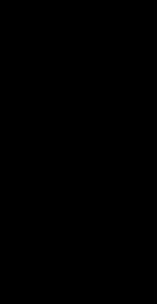

In [86]:
img = Image.fromarray(outlist[0]['segmentation'], 'L')
img

In [134]:
array_3d = np.stack([f['segmentation'] for f in outlist], axis=-1)

In [135]:
print(np.unique(array_3d))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43]


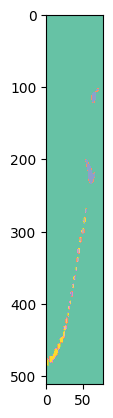

In [27]:
import matplotlib.pyplot as plt
array_3d[array_3d != 1] += 100
array_3d[array_3d == 1] = 50
array_3d[array_3d == 100] = 0

plt.imshow(array_3d[:, 75, :], cmap='Set2')

In [28]:
array_3d2 = np.stack([f['segmentation'] for f in tout], axis=-1)

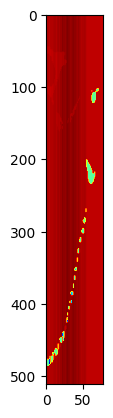

In [29]:
import matplotlib.pyplot as plt
array_3d2[array_3d2 != 1] += 100
array_3d2[array_3d2 == 1] = 50
array_3d2[array_3d2 == 100] = 0

plt.imshow(array_3d2[:, 75, :], cmap='jet')

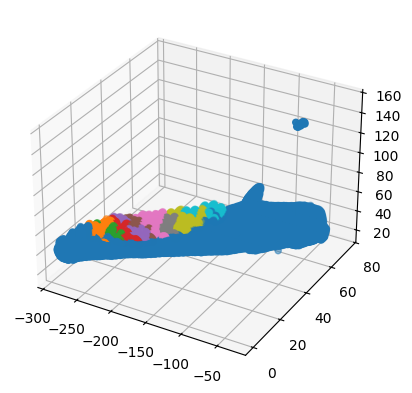

In [136]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# Create a figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Extract x, y, z coordinates
x, y, z = array_3d.nonzero()
ax.scatter(-x, z, y, c=array_3d[x, y, z], cmap='tab10')

plt.show()

In [60]:
!pip install pynrrd

^C


In [103]:
import nrrd
nrrd.write("wd/test.nrrd", array_3d)